# Monthly forecasting of equivalent new maternity leaves in a hospital

## Notebook 01 — Data Cleaning & EDA

This notebook develops the first phase of the project:

1. Loading and initial review of the dataset.
2. Basic transformation of dates and time variables.
3. Visual inspection of the target variable against key explanatory variables.
4. Reasoned selection of candidate variables.
5. Pearson and Spearman correlation analysis.
6. Collinearity analysis using a correlation matrix and VIF.
7. Export of the clean dataset for the modeling phase.

The target variable is:

```text
mat_eq_nuevas_mes
```

which represents monthly equivalent new maternity leaves.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

sns.set_style('whitegrid')

## 2. Dataset loading

In [2]:
# The file must be stored in the data/ folder
# If the file name changes, update this path.

df = pd.read_excel('../data/dataframe.xlsx')

df.head()

,MES,ppef_mujeres_25_40,pct_indef_25_40,pct_amb_fill_25_40,n_maternidades_nuevas,dias_mat_nuevas_mes,mat_eq_nuevas_mes,RE_activo_total_lag1,RE_activo_0_1m_lag1,RE_activo_1_2m_lag1,RE_activo_2_3m_lag1,RE_activo_3m_plus_lag1,RE_ponderado
0,2016-01-31,969.6898,0.1601,0.1505,7.0800,109.7400,3.5400,22.4000,6.7200,10.0800,5.0400,5.3200,15.6240
1,2016-02-29,"1,019.6952",0.1480,0.1099,9.4400,197.0600,6.0628,19.4880,4.4800,9.5200,7.5600,4.4800,16.7160
2,2016-03-31,"1,033.5400",0.1455,0.1173,8.2600,171.1000,5.5194,17.1360,2.9680,7.4480,9.5200,3.3600,16.4640
3,2016-04-30,"1,036.7885",0.1419,0.1133,7.0800,86.1400,2.7350,15.4560,1.2880,3.4160,6.6080,3.3600,11.2560
4,2016-05-31,"1,022.9498",0.1401,0.1218,12.9800,217.1200,7.0039,17.6960,4.2000,5.4880,2.9680,3.3600,9.1560


## 3. Dataset context

Each row represents one month.

The target variable is:

```text
mat_eq_nuevas_mes
```

This variable measures the number of days within the month contributed by new maternity leaves that started in that same month, divided by the number of calendar days in the month.

In addition, the dataset contains potentially relevant explanatory variables:

- `ppef_mujeres_25_40`: equivalent workforce of women aged 25 to 40.
- `pct_indef_25_40`: percentage of women aged 25 to 40 with a permanent contract.
- `pct_amb_fill_25_40`: percentage of women aged 25 to 40 with at least one dependent minor child declared in payroll.
- `RE_ponderado`: synthetic indicator of active pregnancy-risk leave, weighted by seniority.
- `RE_activo_*` variables: active pregnancy-risk situations classified by seniority.

## 4. First dataset inspection

In [3]:
# Dataset dimensions
df.shape

(123, 13)

In [4]:
# Column names
df.columns

Index(['MES', 'ppef_mujeres_25_40', 'pct_indef_25_40', 'pct_amb_fill_25_40',
       'n_maternidades_nuevas', 'dias_mat_nuevas_mes', 'mat_eq_nuevas_mes',
       'RE_activo_total_lag1', 'RE_activo_0_1m_lag1', 'RE_activo_1_2m_lag1',
       'RE_activo_2_3m_lag1', 'RE_activo_3m_plus_lag1', 'RE_ponderado'],
      dtype='object')

In [5]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   MES                     123 non-null    datetime64[ns]
 1   ppef_mujeres_25_40      123 non-null    float64       
 2   pct_indef_25_40         123 non-null    float64       
 3   pct_amb_fill_25_40      123 non-null    float64       
 4   n_maternidades_nuevas   123 non-null    float64       
 5   dias_mat_nuevas_mes     123 non-null    float64       
 6   mat_eq_nuevas_mes       123 non-null    float64       
 7   RE_activo_total_lag1    123 non-null    float64       
 8   RE_activo_0_1m_lag1     121 non-null    float64       
 9   RE_activo_1_2m_lag1     123 non-null    float64       
 10  RE_activo_2_3m_lag1     123 non-null    float64       
 11  RE_activo_3m_plus_lag1  98 non-null     float64       
 12  RE_ponderado            123 non-null    float64   

In [6]:
# Missing values
df.isnull().sum()

MES                        0
ppef_mujeres_25_40         0
pct_indef_25_40            0
pct_amb_fill_25_40         0
n_maternidades_nuevas      0
dias_mat_nuevas_mes        0
mat_eq_nuevas_mes          0
RE_activo_total_lag1       0
RE_activo_0_1m_lag1        2
RE_activo_1_2m_lag1        0
RE_activo_2_3m_lag1        0
RE_activo_3m_plus_lag1    25
RE_ponderado               0
dtype: int64

In [7]:
# Descriptive statistics
df.describe()

,MES,ppef_mujeres_25_40,pct_indef_25_40,pct_amb_fill_25_40,n_maternidades_nuevas,dias_mat_nuevas_mes,mat_eq_nuevas_mes,RE_activo_total_lag1,RE_activo_0_1m_lag1,RE_activo_1_2m_lag1,RE_activo_2_3m_lag1,RE_activo_3m_plus_lag1,RE_ponderado
count,123,123.0000,123.0000,123.0000,123.0000,123.0000,123.0000,123.0000,121.0000,123.0000,123.0000,98.0000,123.0000
mean,2021-02-28 20:17:33.658536704,"1,397.2020",0.2146,0.1057,10.1979,160.3745,5.2209,16.1925,4.6387,7.6298,4.8815,2.1224,10.9350
min,2016-01-31 00:00:00,969.6898,0.0598,0.0546,2.3600,29.5000,0.9516,7.7392,0.8400,1.6800,0.4704,0.2800,2.6880
25%,2018-08-15 12:00:00,"1,141.6895",0.0993,0.0943,7.0800,97.9400,3.1430,13.4400,2.9680,5.4880,3.2536,0.8400,8.6940
50%,2021-02-28 00:00:00,"1,444.3543",0.1366,0.1088,9.4400,155.7600,4.9865,15.9600,4.2000,7.4480,4.8272,1.6800,10.4160
75%,2023-09-15 00:00:00,"1,681.4003",0.3049,0.1197,12.9800,201.1900,6.6865,18.6088,5.8800,9.3800,6.5072,3.1500,13.1880
max,2026-03-31 00:00:00,"1,799.4988",0.6155,0.1531,21.2400,480.2600,15.3380,33.5071,18.8463,21.8367,13.4400,5.8800,21.6720
std,NaN,268.1129,0.1600,0.0203,4.5729,81.6782,2.7318,4.6413,2.5556,3.1189,2.3156,1.3539,3.5419


## 5. Initial cleaning and transformation

In [8]:
# Convert MES to datetime format.
# If MES comes from Excel as a serial number, pandas may misinterpret it directly.
# This logic handles both cases: a normal date or an Excel serial number.

if np.issubdtype(df['MES'].dtype, np.number):
    df['MES'] = pd.to_datetime(df['MES'], unit='D', origin='1899-12-30')
else:
    df['MES'] = pd.to_datetime(df['MES'])

# Sort chronologically
df = df.sort_values('MES').reset_index(drop=True)

# Auxiliary time variables
df['mes'] = df['MES'].dt.month
df['trimestre'] = df['MES'].dt.quarter
df['año'] = df['MES'].dt.year

df.head()

,MES,ppef_mujeres_25_40,pct_indef_25_40,pct_amb_fill_25_40,n_maternidades_nuevas,dias_mat_nuevas_mes,mat_eq_nuevas_mes,RE_activo_total_lag1,RE_activo_0_1m_lag1,RE_activo_1_2m_lag1,RE_activo_2_3m_lag1,RE_activo_3m_plus_lag1,RE_ponderado,mes,trimestre,año
0,2016-01-31,969.6898,0.1601,0.1505,7.0800,109.7400,3.5400,22.4000,6.7200,10.0800,5.0400,5.3200,15.6240,1,1,2016
1,2016-02-29,"1,019.6952",0.1480,0.1099,9.4400,197.0600,6.0628,19.4880,4.4800,9.5200,7.5600,4.4800,16.7160,2,1,2016
2,2016-03-31,"1,033.5400",0.1455,0.1173,8.2600,171.1000,5.5194,17.1360,2.9680,7.4480,9.5200,3.3600,16.4640,3,1,2016
3,2016-04-30,"1,036.7885",0.1419,0.1133,7.0800,86.1400,2.7350,15.4560,1.2880,3.4160,6.6080,3.3600,11.2560,4,2,2016
4,2016-05-31,"1,022.9498",0.1401,0.1218,12.9800,217.1200,7.0039,17.6960,4.2000,5.4880,2.9680,3.3600,9.1560,5,2,2016


In [9]:
# Check time range
print('Minimum date:', df['MES'].min())
print('Maximum date:', df['MES'].max())
print('Number of months:', len(df))

Minimum date: 2016-01-31 00:00:00
Maximum date: 2026-03-31 00:00:00
Number of months: 123


## 6. Initial visual inspection

Before calculating correlations or training models, it is useful to visually inspect the evolution of the target variable together with some relevant explanatory variables.

At this stage, two relationships are especially interesting:

1. The evolution of `mat_eq_nuevas_mes` compared with `ppef_mujeres_25_40`.
2. The evolution of `mat_eq_nuevas_mes` compared with `RE_ponderado`.

The first relationship explores whether the size of the exposed population is associated with more equivalent new maternity leaves.  
The second explores whether pregnancy-risk leave can act as an early signal of the phenomenon.

### 6.1 Evolution of the target variable

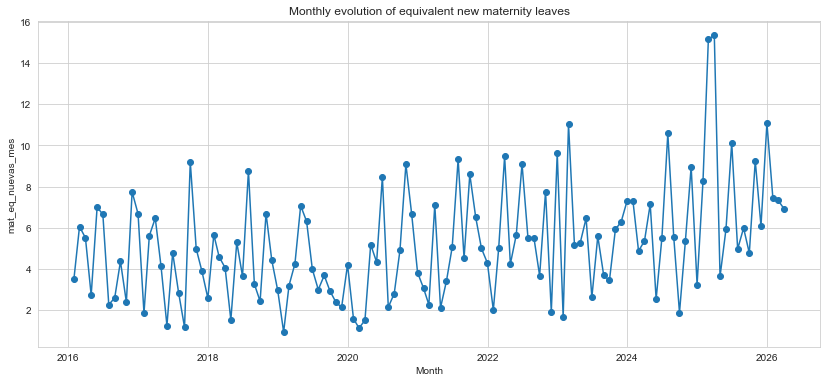

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(
    df['MES'].to_numpy(),
    df['mat_eq_nuevas_mes'].to_numpy(),
    marker='o'
)

plt.title('Monthly evolution of equivalent new maternity leaves')
plt.xlabel('Month')
plt.ylabel('mat_eq_nuevas_mes')

plt.show()

### 6.2 Target variable vs equivalent workforce of women aged 25–40

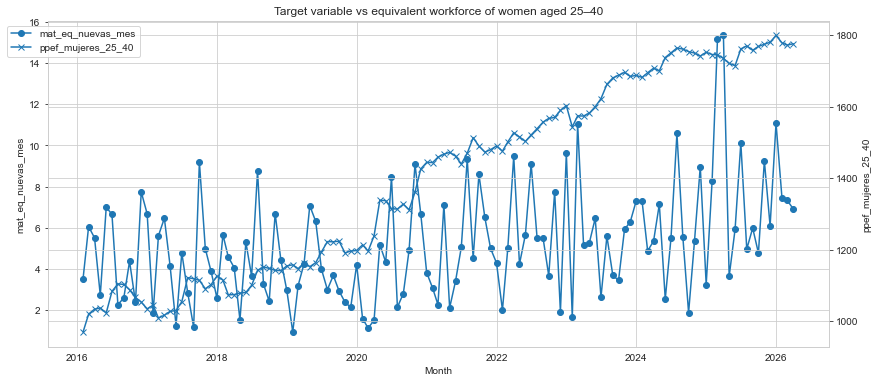

In [11]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    df['MES'].to_numpy(),
    df['mat_eq_nuevas_mes'].to_numpy(),
    marker='o',
    label='mat_eq_nuevas_mes'
)
ax1.set_xlabel('Month')
ax1.set_ylabel('mat_eq_nuevas_mes')

ax2 = ax1.twinx()
ax2.plot(
    df['MES'].to_numpy(),
    df['ppef_mujeres_25_40'].to_numpy(),
    marker='x',
    label='ppef_mujeres_25_40'
)
ax2.set_ylabel('ppef_mujeres_25_40')

plt.title('Target variable vs equivalent workforce of women aged 25–40')

fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.88))
plt.show()

**Expected reading:** if both series tend to move in the same direction, there may be a structural relationship between the size of the exposed population and the monthly volume of equivalent new maternity leaves.

### 6.3 Target variable vs weighted pregnancy-risk leave

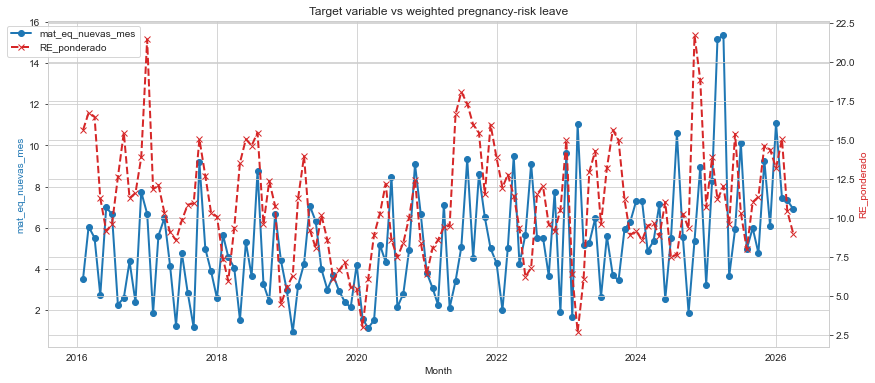

In [12]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Target variable
ax1.plot(
    df['MES'].to_numpy(),
    df['mat_eq_nuevas_mes'].to_numpy(),
    color='tab:blue',
    marker='o',
    linewidth=2,
    label='mat_eq_nuevas_mes'
)

ax1.set_xlabel('Month')
ax1.set_ylabel('mat_eq_nuevas_mes', color='tab:blue')

# Weighted pregnancy-risk leave
ax2 = ax1.twinx()

ax2.plot(
    df['MES'].to_numpy(),
    df['RE_ponderado'].to_numpy(),
    color='tab:red',
    linestyle='--',
    marker='x',
    linewidth=2,
    label='RE_ponderado'
)

ax2.set_ylabel('RE_ponderado', color='tab:red')

plt.title('Target variable vs weighted pregnancy-risk leave')

fig.legend(
    loc='upper left',
    bbox_to_anchor=(0.08, 0.88)
)

plt.show()

**Expected reading:** if `RE_ponderado` partially anticipates movements in `mat_eq_nuevas_mes`, it may be a useful variable for the model. Its relationship may appear more clearly using lags (`lag1`, `lag2`, `lag3`) than using the contemporaneous value.

### 6.4 Initial scatter plots between main variables and the target

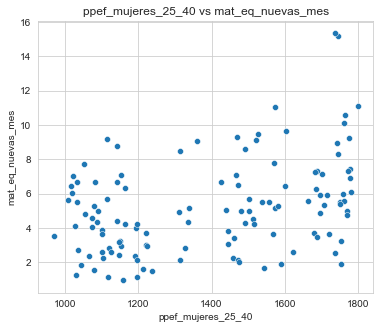

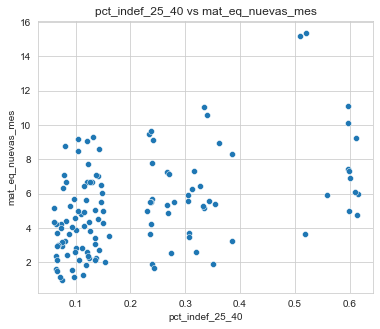

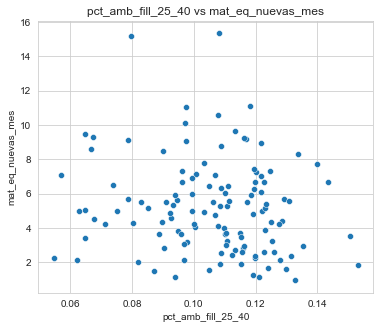

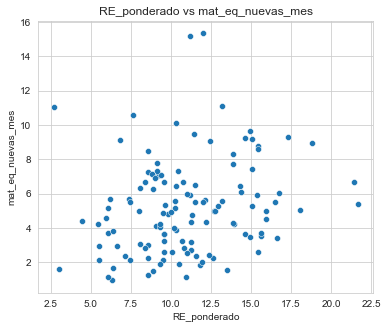

In [13]:
scatter_vars = [
    'ppef_mujeres_25_40',
    'pct_indef_25_40',
    'pct_amb_fill_25_40',
    'RE_ponderado'
]

for var in scatter_vars:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        data=df,
        x=var,
        y='mat_eq_nuevas_mes'
    )
    plt.title(f'{var} vs mat_eq_nuevas_mes')
    plt.show()

## 7. Creation of relevant variables for modeling

After the initial visual and statistical inspection, additional variables are created that may help predict the target variable.

### Candidate variables and rationale

- `ppef_mujeres_25_40`: measures the size of the exposed population.
- `pct_indef_25_40`: approximates the contractual stability of the target population.
- `pct_amb_fill_25_40`: administrative proxy for family structure.
- `RE_ponderado_lag1`, `RE_ponderado_lag2`, `RE_ponderado_lag3`: allow testing different lags between pregnancy-risk leave and maternity leave.
- `mat_eq_lag1`: captures recent temporal inertia.
- `mat_eq_lag12`: captures a possible annual pattern or year-over-year seasonality.
- `mes`: captures monthly seasonality.

In [14]:
# Lagged variables of the target variable
df['mat_eq_lag1'] = df['mat_eq_nuevas_mes'].shift(1)
df['mat_eq_lag12'] = df['mat_eq_nuevas_mes'].shift(12)

# Lags of the weighted pregnancy-risk indicator
df['RE_ponderado_lag1'] = df['RE_ponderado'].shift(1)
df['RE_ponderado_lag2'] = df['RE_ponderado'].shift(2)
df['RE_ponderado_lag3'] = df['RE_ponderado'].shift(3)

# Replace only the null values generated by lags with 0
lag_cols = [
    'mat_eq_lag1',
    'mat_eq_lag12',
    'RE_ponderado_lag1',
    'RE_ponderado_lag2',
    'RE_ponderado_lag3'
]

df[lag_cols] = df[lag_cols].fillna(0)

# Dataset for analysis and modeling
df_model = df.copy()

df_model.head()

,MES,ppef_mujeres_25_40,pct_indef_25_40,pct_amb_fill_25_40,n_maternidades_nuevas,dias_mat_nuevas_mes,mat_eq_nuevas_mes,RE_activo_total_lag1,RE_activo_0_1m_lag1,RE_activo_1_2m_lag1,RE_activo_2_3m_lag1,RE_activo_3m_plus_lag1,RE_ponderado,mes,trimestre,año,mat_eq_lag1,mat_eq_lag12,RE_ponderado_lag1,RE_ponderado_lag2,RE_ponderado_lag3
0,2016-01-31,969.6898,0.1601,0.1505,7.0800,109.7400,3.5400,22.4000,6.7200,10.0800,5.0400,5.3200,15.6240,1,1,2016,0.0000,0.0000,0.0000,0.0000,0.0000
1,2016-02-29,"1,019.6952",0.1480,0.1099,9.4400,197.0600,6.0628,19.4880,4.4800,9.5200,7.5600,4.4800,16.7160,2,1,2016,3.5400,0.0000,15.6240,0.0000,0.0000
2,2016-03-31,"1,033.5400",0.1455,0.1173,8.2600,171.1000,5.5194,17.1360,2.9680,7.4480,9.5200,3.3600,16.4640,3,1,2016,6.0628,0.0000,16.7160,15.6240,0.0000
3,2016-04-30,"1,036.7885",0.1419,0.1133,7.0800,86.1400,2.7350,15.4560,1.2880,3.4160,6.6080,3.3600,11.2560,4,2,2016,5.5194,0.0000,16.4640,16.7160,15.6240
4,2016-05-31,"1,022.9498",0.1401,0.1218,12.9800,217.1200,7.0039,17.6960,4.2000,5.4880,2.9680,3.3600,9.1560,5,2,2016,2.7350,0.0000,11.2560,16.4640,16.7160


In [15]:
print('Original rows:', len(df))
print('Rows after creating lags and handling missing values:', len(df_model))

Original rows: 123
Rows after creating lags and handling missing values: 123


## 8. Correlation analysis with the target variable

Correlations between the target variable and the candidate explanatory variables are calculated using two methods:

- **Pearson:** measures linear association.
- **Spearman:** measures monotonic association and is less sensitive to outliers or extreme values.

This analysis does not prove causality, but it helps identify which variables contain more predictive signal.

In [16]:
target = 'mat_eq_nuevas_mes'

candidate_features = [
    'ppef_mujeres_25_40',
    'pct_indef_25_40',
    'pct_amb_fill_25_40',
    'RE_ponderado',
    'RE_ponderado_lag1',
    'RE_ponderado_lag2',
    'RE_ponderado_lag3',
    'mat_eq_lag1',
    'mat_eq_lag12',
    'mes'
]

corr_features = [target] + candidate_features

pearson_corr = df_model[corr_features].corr(method='pearson')
spearman_corr = df_model[corr_features].corr(method='spearman')

### 8.1 Pearson correlation

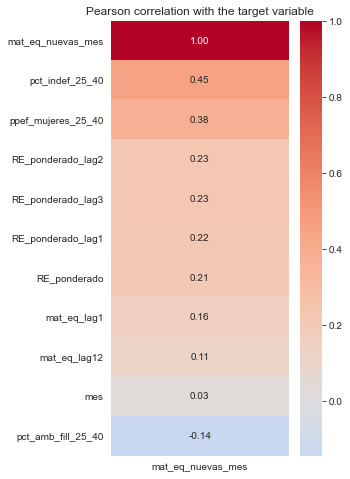

In [17]:
# Pearson correlation only against the target variable

target_corr = pearson_corr[['mat_eq_nuevas_mes']].sort_values(
    by='mat_eq_nuevas_mes',
    ascending=False
)

plt.figure(figsize=(4, 8))

sns.heatmap(
    target_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Pearson correlation with the target variable')
plt.show()

In [18]:
pearson_target = (
    pearson_corr[target]
    .drop(target)
    .sort_values(ascending=False)
)

pearson_target

pct_indef_25_40       0.4488
ppef_mujeres_25_40    0.3808
RE_ponderado_lag2     0.2322
RE_ponderado_lag3     0.2307
RE_ponderado_lag1     0.2195
RE_ponderado          0.2105
mat_eq_lag1           0.1590
mat_eq_lag12          0.1127
mes                   0.0284
pct_amb_fill_25_40   -0.1427
Name: mat_eq_nuevas_mes, dtype: float64

### 8.2 Spearman correlation

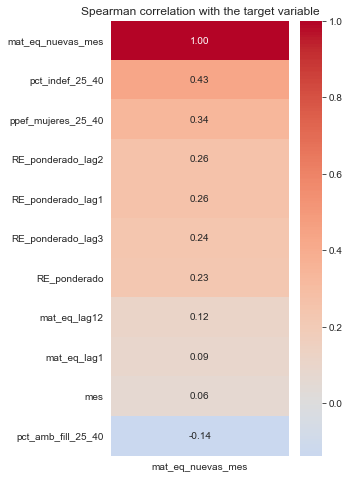

In [19]:
# Spearman correlation only against the target variable

target_corr_spearman = spearman_corr[['mat_eq_nuevas_mes']].sort_values(
    by='mat_eq_nuevas_mes',
    ascending=False
)

plt.figure(figsize=(4, 8))

sns.heatmap(
    target_corr_spearman,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Spearman correlation with the target variable')
plt.show()

In [20]:
spearman_target = (
    spearman_corr[target]
    .drop(target)
    .sort_values(ascending=False)
)

spearman_target

pct_indef_25_40       0.4327
ppef_mujeres_25_40    0.3405
RE_ponderado_lag2     0.2611
RE_ponderado_lag1     0.2610
RE_ponderado_lag3     0.2397
RE_ponderado          0.2323
mat_eq_lag12          0.1156
mat_eq_lag1           0.0928
mes                   0.0631
pct_amb_fill_25_40   -0.1373
Name: mat_eq_nuevas_mes, dtype: float64

## 9. Collinearity analysis among explanatory variables

In multiple linear regression, it is not only important that variables are related to the target variable. It is also important that explanatory variables are not excessively redundant with each other.

If two predictors contain almost the same information, the model coefficients may become unstable.

This section analyzes collinearity using:

1. Correlation matrix among predictors.
2. VIF — Variance Inflation Factor.

The target variable is excluded from this analysis.

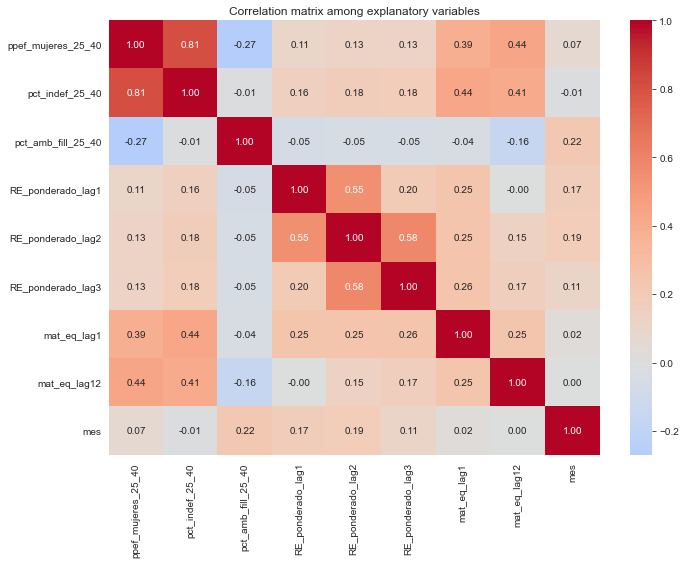

In [21]:
features_collinearity = [
    'ppef_mujeres_25_40',
    'pct_indef_25_40',
    'pct_amb_fill_25_40',
    'RE_ponderado_lag1',
    'RE_ponderado_lag2',
    'RE_ponderado_lag3',
    'mat_eq_lag1',
    'mat_eq_lag12',
    'mes'
]

corr_predictors = df_model[features_collinearity].corr(method='pearson')

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_predictors,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation matrix among explanatory variables')
plt.show()

### 9.1 VIF calculation

In [22]:
X_vif = df_model[features_collinearity].copy()

# Add constant to calculate VIF
X_vif_const = sm.add_constant(X_vif)

vif_df = pd.DataFrame({
    'variable': X_vif_const.columns,
    'VIF': [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(X_vif_const.shape[1])
    ]
})

vif_df = vif_df.sort_values('VIF', ascending=False)

vif_df

,variable,VIF
0,const,178.7170
1,ppef_mujeres_25_40,4.2127
2,pct_indef_25_40,4.0017
5,RE_ponderado_lag2,2.1677
6,RE_ponderado_lag3,1.6137
4,RE_ponderado_lag1,1.5815
3,pct_amb_fill_25_40,1.4555
7,mat_eq_lag1,1.3447
8,mat_eq_lag12,1.3092
9,mes,1.2154


### 9.2 Decision criterion

As a rule of thumb:

- VIF close to 1: no relevant collinearity.
- VIF between 5 and 10: possible collinearity to review.
- VIF above 10: high collinearity.

The decision to exclude variables should not be automatic. It should combine:

1. VIF.
2. Interpretability.
3. Correlation with the target variable.
4. Operational usefulness.
5. Out-of-sample model results.

If a variable has a very high VIF and also contributes little predictive signal, it will be a candidate for exclusion from the final model.

### 9.3 Automatic proposal of variables to review

In [23]:
high_vif_threshold = 10

variables_to_review = vif_df[
    (vif_df['variable'] != 'const') &
    (vif_df['VIF'] > high_vif_threshold)
]

variables_to_review

,variable,VIF


## 10. Preparation of the complete dataframe for modeling

Based on the exploratory analysis above, this notebook does not close a single definitive selection of variables.

The purpose of this phase is to prepare a broad and clean dataframe with all potentially relevant variables so that, in the next notebook, different combinations of variables can be tested systematically.

This separates two tasks:

1. **Notebook 1:** prepare, understand, and document the dataset.
2. **Notebook 2:** build multiple linear regression models and search for the combination of variables that performs best out of sample.

Therefore, instead of exporting a reduced selection, a complete dataset with candidate variables will be exported.

### 10.1 Candidate variables to be exported

The exported dataset will include:

- The time variable `MES`.
- The target variable `mat_eq_nuevas_mes`.
- Structural workforce variables.
- Labor variables.
- The administrative proxy for family structure.
- Lagged variables for pregnancy-risk leave and the target variable.
- Calendar variables.

In the modeling notebook, different multiple linear regression specifications will be compared by combining these variables.

In [24]:
model_features_full = [
    # Time identifier
    'MES',

    # Target variable
    'mat_eq_nuevas_mes',

    # Structural, labor, and family variables
    'ppef_mujeres_25_40',
    'pct_indef_25_40',
    'pct_amb_fill_25_40',

    # Lags of the weighted pregnancy-risk indicator
    'RE_ponderado_lag1',
    'RE_ponderado_lag2',
    'RE_ponderado_lag3',

    # Lags of the target variable
    'mat_eq_lag1',
    'mat_eq_lag12',

    # Calendar variables
    'mes'
]

# Check that all columns exist before exporting
missing_cols = [col for col in model_features_full if col not in df_model.columns]

if missing_cols:
    print("Columns not found in df_model:")
    print(missing_cols)
else:
    print("All candidate columns are available.")

All candidate columns are available.


In [25]:
# Build complete dataframe for the modeling notebook

df_model_full = df_model[model_features_full].copy()

df_model_full.head()

,MES,mat_eq_nuevas_mes,ppef_mujeres_25_40,pct_indef_25_40,pct_amb_fill_25_40,RE_ponderado_lag1,RE_ponderado_lag2,RE_ponderado_lag3,mat_eq_lag1,mat_eq_lag12,mes
0,2016-01-31,3.5400,969.6898,0.1601,0.1505,0.0000,0.0000,0.0000,0.0000,0.0000,1
1,2016-02-29,6.0628,"1,019.6952",0.1480,0.1099,15.6240,0.0000,0.0000,3.5400,0.0000,2
2,2016-03-31,5.5194,"1,033.5400",0.1455,0.1173,16.7160,15.6240,0.0000,6.0628,0.0000,3
3,2016-04-30,2.7350,"1,036.7885",0.1419,0.1133,16.4640,16.7160,15.6240,5.5194,0.0000,4
4,2016-05-31,7.0039,"1,022.9498",0.1401,0.1218,11.2560,16.4640,16.7160,2.7350,0.0000,5


In [26]:
df_model_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   MES                 123 non-null    datetime64[ns]
 1   mat_eq_nuevas_mes   123 non-null    float64       
 2   ppef_mujeres_25_40  123 non-null    float64       
 3   pct_indef_25_40     123 non-null    float64       
 4   pct_amb_fill_25_40  123 non-null    float64       
 5   RE_ponderado_lag1   123 non-null    float64       
 6   RE_ponderado_lag2   123 non-null    float64       
 7   RE_ponderado_lag3   123 non-null    float64       
 8   mat_eq_lag1         123 non-null    float64       
 9   mat_eq_lag12        123 non-null    float64       
 10  mes                 123 non-null    int32         
dtypes: datetime64[ns](1), float64(9), int32(1)
memory usage: 10.2 KB


## 11. Export complete dataset for the modeling notebook

A single broad CSV file with all candidate variables is exported.

This file will be the main input for the next notebook:

```text
notebooks/02_modeling_rlm.ipynb
```

In that notebook, a systematic search of variable combinations will be performed to compare different multiple linear regression models.

In [27]:
df_model_full.to_csv(
    '../data/df_model_full.csv',
    index=False
)

print("Dataset exported to: ../data/df_model_full.csv")

Dataset exported to: ../data/df_model_full.csv


## 13. Preliminary EDA conclusions

Based on the exploratory analysis, several useful conclusions can be drawn before moving on to the modeling phase.

### 1. The target variable has enough variability

The variable `mat_eq_nuevas_mes` has enough monthly variability to attempt building a predictive model.

It is not a flat series or an almost constant variable. There are months with clearly higher values and months with lower values, so it makes sense to explore whether part of that variability can be explained by structural, labor, family, and administrative variables.

Even so, it should be assumed from the beginning that monthly new maternity leaves are a phenomenon with real uncertainty. The purpose of the model will not be to predict each month perfectly, but to improve simple prediction rules and provide a useful aggregate estimate.

---

### 2. Visual inspection suggests plausible relationships

The visual comparison between `mat_eq_nuevas_mes` and `ppef_mujeres_25_40` helps explore whether the size of the exposed population is related to the monthly volume of equivalent new maternity leaves.

The comparison between `mat_eq_nuevas_mes` and `RE_ponderado` helps observe whether pregnancy-risk leave can function as an early signal. The relationship does not necessarily have to be contemporaneous; therefore, lags of `RE_ponderado` (`lag1`, `lag2`, `lag3`) have been created to test different time delays.

---

### 3. Correlations provide guidance, but do not select the final model

Pearson and Spearman analysis helps identify which variables show greater association with the target variable.

Structural variables such as `ppef_mujeres_25_40` and `pct_indef_25_40` may capture background changes in the exposed population and in labor stability. The variable `pct_amb_fill_25_40` provides an administrative proxy for family structure. The variables `RE_ponderado_lag1`, `RE_ponderado_lag2`, and `RE_ponderado_lag3` allow us to analyze whether pregnancy-risk leave anticipates new maternity leaves with some delay.

These correlations should not be interpreted as causality or as a definitive selection of variables. They serve to guide the modeling phase.

---

### 4. Collinearity should be monitored during model comparison

Collinearity analysis using the correlation matrix and VIF makes it possible to detect whether some explanatory variables contain redundant information.

If a variable has a high VIF, it should not be automatically removed. The final decision should combine:

- VIF magnitude,
- substantive interpretation,
- correlation with the target variable,
- model stability,
- out-of-sample performance.

In particular, attention should be paid to possible relationships among structural variables such as `ppef_mujeres_25_40`, `pct_indef_25_40`, and `pct_amb_fill_25_40`, as well as among the different lags of `RE_ponderado`.

---

### 5. This notebook exports a broad dataframe, not a closed selection

The main methodological decision in this notebook is not to close a single model specification yet.

Instead, it exports:

```text
data/df_model_full.csv
```

This file contains all clean and transformed candidate variables so that Notebook 2 can compare combinations of variables in multiple linear regression models.

---

### 6. Next step: systematic search of MLR specifications

In the next notebook, combinations of candidate variables will be tested using two multiple linear regression approaches:

- `scikit-learn LinearRegression`
- `statsmodels OLS`

The final selection should balance:

- lower out-of-sample error,
- parsimony,
- low collinearity,
- stability,
- substantive interpretation,
- operational usefulness.

The objective will not be to find the most complex model, but the most useful, explainable, and robust model to anticipate monthly equivalent new maternity leaves.